In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
import pymatching

GKP logical qubits are continous variables

$$ \ket{0}_L = \sum^{\infty}_{k = 0} \ket{2k\pi} \qquad \ket{1}_L = \sum^{\infty}_{k = 0} \ket{(2k+1)\pi}$$

we can simulate these by picking a large value N instead of infinity, and parameters to squeeze and build the peaks of these states.

These quits manifest as lattice sites in phase space, that can be displayed as a porbability density function called the Wiegner (check spelling) function. This gives the probability of the qubit exisiting in given momentum (or momenta -check) and position. 

All qubits experience errors on their information. In these gkp qubits, the errors can appear in both momentum and position, cannot correct for both uncertinty princile

Squeeze the qubit so most of it lies iin just one of the axis in phase space - then most errors just in one side

Also qutip uses 

$$ \alpha = \frac{q + ip}{\sqrt{2}} $$

as a paremeter for translating position and momentum space into coordinates that fit its system.

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

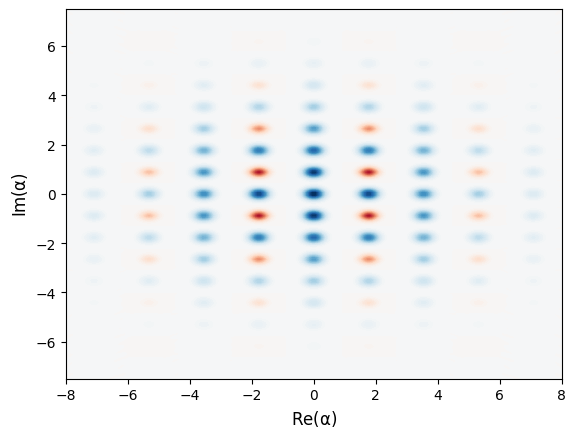

In [ ]:
class GKP_qubits:
    Number_states: int =  None
    Squeezing_parameter: float = None
    Envelope_parameter: float = None
    Qubit_peaks: int = None
    Noise_gaussian_spread: float = None
    Number_shots: int = None

    def __init__(self, Number_states: int, Squeezing_parameter: float, Envelope_parameter: float, Qubit_peaks: int, Noise_gaussian_spread: float, Number_shots: int):
        self.Number_states = Number_states
        self.Squeezing_parameter = Squeezing_parameter
        self.Envelope_parameter = Envelope_parameter
        self.Qubit_peaks = Qubit_peaks
        self.Noise_gaussian_spread = Noise_gaussian_spread
        self.Number_shots = Number_shots
    
    def pos_to_alpha(self, q, p=0):
        return (q + 1j* p) /sqrt_2 

    def build(self):
        vac = basis(self.Number_states, 0)
        r = -np.log(self.Squeezing_parameter)
        S = squeeze(self.Number_states, r)
        peak_state = S * vac

        k_vals = np.arange(-self.Qubit_peaks, self.Qubit_peaks + 1)

        weights = np.exp(-2 * np.pi * self.Envelope_parameter**2 * k_vals**2)

        alphas = self.pos_to_alpha(2 * k_vals * sqrt_pi)

        displaced_states = np.hstack([(displace(self.Number_states, alpha) * peak_state).unit().full() for alpha in alphas])

        #Lucca said one column per qubit and each row is a variable

        self.state_array = (displaced_states @ weights).reshape(-1, 1)

        return self
    
    def to_qobj(self):
        #so that i can do wigner function
        gkp = qutip.Qobj(self.state_array)
        gkp.dims = [[self.Number_states], [1]]
        return gkp

N =200 # needs to be large
delta = 0.3 # to sqeeeze
epsilon = 0.2 
n = 6 #gkp qubit peaks
sigma = 0.4 # for displacement noise
n_trials = 5000 # for monte carlo

sqrt_pi = np.sqrt(np.pi) # to write less later on
sqrt_2 = np.sqrt(2)

GKP = GKP_qubits(N, delta, epsilon, n, sigma, n_trials)
GKP.build()

state = GKP.to_qobj()
qutip.plot_wigner(state, xvec=np.linspace(-8, 8, 200))

In [1]:
Sq = displace(N, GKP.pos_to_alpha(2*sqrt_pi, 0))
Sp = displace(N, GKP.pos_to_alpha(0, 2*sqrt_pi))

NameError: name 'displace' is not defined